In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
%matplotlib inline

# Задание 1. Краевая задача методом конечных разностей

$$y'' + (1-4x)y' + 8y = 5, \quad 0 < x < 1$$
$$y'(0) - y(0) = 0, \quad y(1) = 0$$

Аппроксимация центральными разностями:
$$\frac{y_{i+1} - 2y_i + y_{i-1}}{h^2} + (1-4x_i)\frac{y_{i+1}-y_{i-1}}{2h} + 8y_i = 5$$

Левое граничное условие $y'(0) = y(0)$: аппроксимируем $y'(0) \approx \frac{y_1 - y_0}{h}$, поэтому $y_1 = y_0(1+h)$. Подставляя в уравнение для $i=0$:
$$\frac{y_1 - 2y_0 + y_0(1+h)}{h^2}\cdot\ldots$$
Или напрямую: используем одностороннюю аппроксимацию $y'(0) \approx (y_1 - y_0)/h$, откуда строка матрицы для $y_0$.

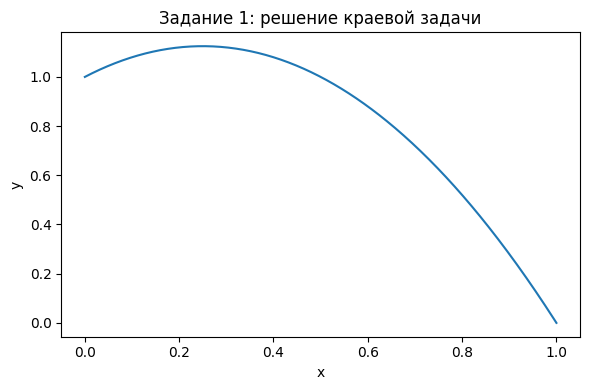

y(0) = 1.000000,  y'(0) ≈ 0.996000
y'(0) - y(0) = -4.00e-03
y(1) = 0.00e+00


In [5]:
def solve_bvp_fd(N):
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)
    m = N 

    d  = np.full(m, -2/h**2 + 8.0)
    up = np.zeros(m - 1)
    lo = np.zeros(m - 1)
    rhs = np.full(m, 5.0)

    # Левое граничное условие: y'(0) - y(0) = 0
    d[0]  = -2/h**2 - 2/h + 9
    up[0] = 2/h**2

    for i in range(1, m - 1):
        pi = (1 - 4*x[i]) / (2*h)
        lo[i-1] = 1/h**2 - pi
        up[i]   = 1/h**2 + pi

    i = m - 1
    pi = (1 - 4*x[i]) / (2*h)
    lo[i-1] = 1/h**2 - pi

    A = np.diag(d) + np.diag(up, 1) + np.diag(lo, -1)
    ys = np.linalg.solve(A, rhs)
    y = np.append(ys, 0.0)
    return x, y


x_c, y_c = solve_bvp_fd(500)

plt.figure(figsize=(6, 4))
plt.plot(x_c, y_c)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Задание 1: решение краевой задачи')
plt.tight_layout()
plt.show()

print(f"y(0) = {y_c[0]:.6f},  y'(0) ≈ {(y_c[1]-y_c[0])/(x_c[1]-x_c[0]):.6f}")
print(f"y'(0) - y(0) = {(y_c[1]-y_c[0])/(x_c[1]-x_c[0]) - y_c[0]:.2e}")
print(f"y(1) = {y_c[-1]:.2e}")

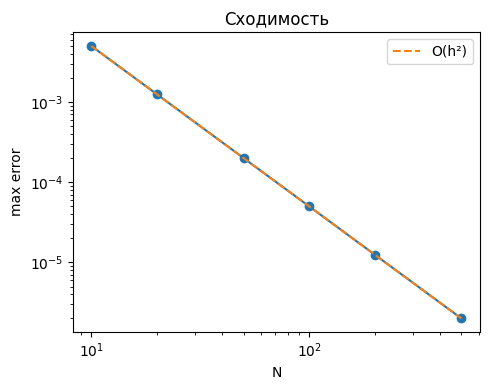

In [6]:
# Исследование сходимости
Ns = [10, 20, 50, 100, 200, 500]
y_ref = solve_bvp_fd(2000)[1]
x_ref = np.linspace(0, 1, 2001)

errors = []
for N in Ns:
    x_n, y_n = solve_bvp_fd(N)
    y_interp = np.interp(x_ref, x_n, y_n)
    errors.append(np.max(np.abs(y_interp - y_ref)))

plt.figure(figsize=(5, 4))
plt.loglog(Ns, errors, 'o-')
plt.loglog(Ns, [errors[0]*(Ns[0]/N)**2 for N in Ns], '--', label='O(h²)')
plt.xlabel('N'); plt.ylabel('max error')
plt.legend(); plt.title('Сходимость')
plt.tight_layout()
plt.show()

---
# Задание 2. Метод дифференциальной прогонки

$$y'' = -y + x\cos x, \quad y'(0) = 3y(0) + 2, \quad y'(\pi/2) = -5y(\pi/2) + 2$$

Точное решение: $y = -0.73\cos x - 0.441\sin x + \frac{1}{4}(x^2\sin x + x\cos x)$

**Метод:** ищем $y' = \alpha(x) y + \beta(x)$. Подставляя $y'' = \alpha' y + \alpha y' + \beta' = \alpha' y + \alpha(\alpha y + \beta) + \beta'$ в уравнение:

$$\alpha' = -1 - \alpha^2, \quad \beta' = x\cos x - \alpha\beta$$

с начальными условиями $\alpha(0) = 3$, $\beta(0) = 2$ (из левого ГУ).

Правое ГУ: $y'(\pi/2) = -5y(\pi/2) + 2 \Rightarrow \alpha(\pi/2)y(\pi/2) + \beta(\pi/2) = -5y(\pi/2) + 2$.

y(π/2) = 0.175361  (точное: 0.175000)


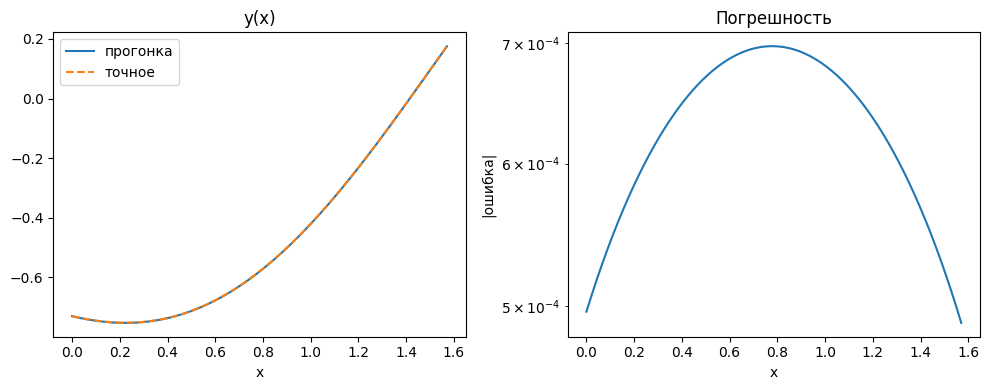

y(0)   = -0.730496
y'(π/2) = 1.123196  (точное: 1.122000)
Max error = 6.97e-04


In [7]:
def forward_rhs(x, s):
    a, b = s
    return [-1 - a**2, x*np.cos(x) - a*b]

sol_fwd = solve_ivp(forward_rhs, [0, np.pi/2], [3.0, 2.0],
                    method='RK45', rtol=1e-12, atol=1e-14, dense_output=True)

a_end, b_end = sol_fwd.sol(np.pi/2)
y_R = (2 - b_end) / (5 + a_end)
print(f"y(π/2) = {y_R:.6f}  (точное: 0.175000)")

def back_rhs(x, y):
    a, b = sol_fwd.sol(x)
    return [a*y[0] + b]

sol_back = solve_ivp(back_rhs, [np.pi/2, 0], [y_R],
                     method='RK45', rtol=1e-12, atol=1e-14, dense_output=True)

xx = np.linspace(0, np.pi/2, 500)
y_sweep = sol_back.sol(xx)[0]
y_exact = -0.73*np.cos(xx) - 0.441*np.sin(xx) + 0.25*(xx**2*np.sin(xx) + xx*np.cos(xx))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(xx, y_sweep, label='прогонка')
axes[0].plot(xx, y_exact, '--', label='точное')
axes[0].set_xlabel('x'); axes[0].legend()
axes[0].set_title('y(x)')

axes[1].semilogy(xx, np.abs(y_sweep - y_exact) + 1e-16)
axes[1].set_xlabel('x'); axes[1].set_ylabel('|ошибка|')
axes[1].set_title('Погрешность')

plt.tight_layout()
plt.show()

print(f"y(0)   = {sol_back.sol(0)[0]:.6f}")
print(f"y'(π/2) = {a_end*y_R + b_end:.6f}  (точное: 1.122000)")
print(f"Max error = {np.max(np.abs(y_sweep - y_exact)):.2e}")

---
# Задание 3. Нелинейное уравнение Пуассона — метод стрельбы + Ньютон

$$\phi''(x) = e^{\phi(x)} - n(x), \quad n(x) = 1 + e^{-3(x-5)^2}$$
$$\phi(0) = 0, \quad \phi(10) = 0$$

Ищем $\phi'(0) = s$ такое, что $\phi(10; s) = 0$.

**Уравнение в вариациях** для $\psi = \partial\phi/\partial s$:
$$\psi'' = e^{\phi} \psi, \quad \psi(0) = 0, \quad \psi'(0) = 1$$

Итерация Ньютона: $s_{k+1} = s_k - \phi(10; s_k)/\psi(10; s_k)$.

In [11]:
def n_func(x):
    return 1.0 + np.exp(-3*(x - 5)**2)


def shoot(s):
    def rhs(x, y):
        phi, dphi, psi, dpsi = y
        return [dphi, np.exp(phi) - n_func(x), dpsi, np.exp(phi)*psi]
    sol = solve_ivp(rhs, [0, 10], [0, s, 0, 1],
                    method='DOP853', rtol=1e-13, atol=1e-15, max_step=0.002)
    if sol.t[-1] < 9.9:
        return None
    return sol.y[0, -1], sol.y[2, -1], sol


a_br, b_br = 0.006, 0.00653
s = a_br

print(f"{'k':>3}  {'s':>18}  {'|F|':>14}")
iters = []
for k in range(20):
    res = shoot(s)
    if res is None:
        s = (a_br + b_br) / 2
        continue
    F, dF, sol_k = res
    iters.append((k, s, abs(F)))
    if F < 0: a_br = s
    else:     b_br = s
    s_new = s - F / dF
    s = s_new
    print(f"{k:>3}  {s:>18.14f}  {abs(F):>14.4e}")
    if abs(F) < 1e-13:
        break

s_star = s
print(f"\nφ'(0) = {s_star:.14f}")

  k                   s             |F|
  0    0.00686856081378      4.4902e+00
  2    0.00663057969438      2.8316e+00
  3    0.00657899888257      3.5616e+00
  4    0.00653131146212      1.3649e+00
  5    0.00651816526804      2.5400e-01
  6    0.00651759079379      1.0232e-02
  7    0.00651758982195      1.7251e-05
  8    0.00651758982195      4.9798e-11
  9    0.00651758982195      6.4031e-13
 10    0.00651758982195      4.6745e-13
 11    0.00651758982195      2.9578e-13
 12    0.00651758982195      3.8010e-14

φ'(0) = 0.00651758982195


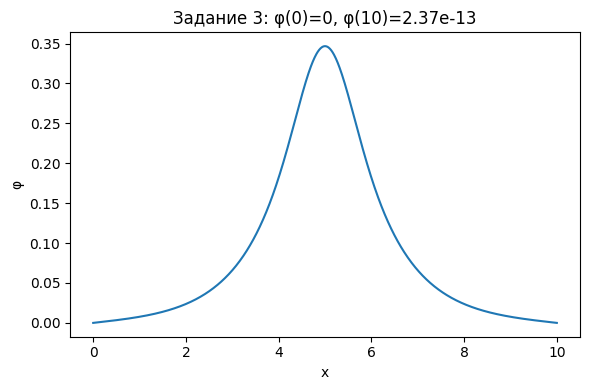

φ'(0) = 0.0065175898
φ(10) = 2.37e-13
max φ = 0.346685 при x ≈ 5.01


In [9]:
def rhs_simple(x, y):
    return [y[1], np.exp(y[0]) - n_func(x)]

sol_star = solve_ivp(rhs_simple, [0, 10], [0, s_star],
                     method='DOP853', rtol=1e-13, atol=1e-15, max_step=0.005,
                     dense_output=True)
xx = np.linspace(0, 10, 1000)
phi_sol = sol_star.sol(xx)[0]

plt.figure(figsize=(6, 4))
plt.plot(xx, phi_sol)
plt.xlabel('x'); plt.ylabel('φ')
plt.title(f"Задание 3: φ(0)=0, φ(10)={sol_star.sol(10)[0]:.2e}")
plt.tight_layout()
plt.show()

print(f"φ'(0) = {s_star:.10f}")
print(f"φ(10) = {sol_star.sol(10)[0]:.2e}")
print(f"max φ = {phi_sol.max():.6f} при x ≈ {xx[phi_sol.argmax()]:.2f}")

In [ ]:
sol_ref = solve_ivp(rhs_simple, [0, 10], [0, s_star],
                    method='DOP853', rtol=1e-14, atol=1e-16,
                    dense_output=True)
phi_ref_at_10 = sol_ref.sol(10)[0]

def solve_with_maxstep(max_step):
    sol = solve_ivp(rhs_simple, [0, 10], [0, s_star],
                    method='DOP853', rtol=1e-13, atol=1e-15,
                    max_step=max_step, dense_output=True)
    phi_at_10 = sol.sol(10)[0]
    error = abs(phi_at_10 - phi_ref_at_10)
    n_steps = len(sol.t) - 1
    return n_steps, error

max_step_guess = 0.1
found = False
for _ in range(30): 
    n, err = solve_with_maxstep(max_step_guess)
    if err <= 1e-10:
        max_step_guess *= 1.5
    else:
        max_step_guess *= 0.7
    if max_step_guess > 1.0:
        max_step_guess = 1.0
        break

best_max_step = None
best_n_steps = None
for ms in [0.01, 0.02, 0.05, 0.07, 0.1, 0.12, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    n, err = solve_with_maxstep(ms)
    if err <= 1e-10:
        best_max_step = ms
        best_n_steps = n
        break

if best_max_step is None:
    best_max_step = max_step_guess
    best_n_steps, _ = solve_with_maxstep(best_max_step)

print(f"Количество шагов интегрирования: {best_n_steps}")

Количество шагов интегрирования: 1001


---
# Задание 4. Нелинейное уравнение Пуассона — метод Ньютона на сетке

$$\phi''(x) = e^{\phi(x)} - n(x), \quad \phi(0) = \phi(10) = 0$$

Конечно-разностная дискретизация на равномерной сетке $x_i = ih$, $h = 10/N$:
$$F_i(\boldsymbol{\phi}) = \frac{\phi_{i-1} - 2\phi_i + \phi_{i+1}}{h^2} - e^{\phi_i} + n_i = 0$$

Якобиан: $J_{ii} = -2/h^2 - e^{\phi_i}$, $J_{i,i\pm1} = 1/h^2$.

Итерация: $\boldsymbol{\phi}^{(k+1)} = \boldsymbol{\phi}^{(k)} - J^{-1}F$.

  k        ||δφ||_∞
  1      3.7994e-01
  2      3.2813e-02
  3      3.4308e-04
  4      3.8328e-08
  5      3.3747e-16


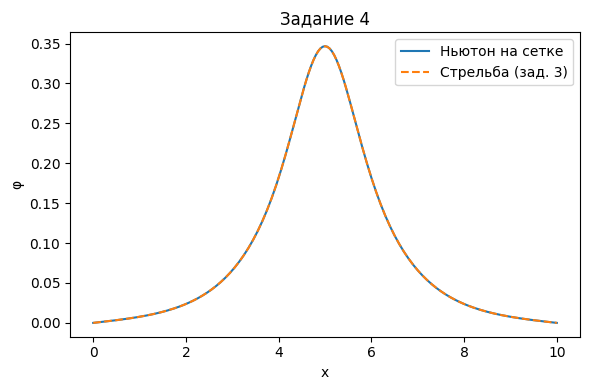


Max разница с зад. 3: 8.80e-05


In [ ]:
N4 = 200
h4 = 10.0 / N4
xg = np.linspace(0, 10, N4 + 1)
xin = xg[1:-1]
ni = n_func(xin)

phi = np.zeros(N4 - 1)

print(f"{'k':>3}  {'||δφ||_∞':>14}")
norms = []
for k in range(30):
    pe = np.concatenate([[0], phi, [0]])
    F4 = (pe[2:] - 2*pe[1:-1] + pe[:-2]) / h4**2 - np.exp(phi) + ni
    diag = -2/h4**2 - np.exp(phi)
    off  = np.ones(N4 - 2) / h4**2
    J = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)
    delta = np.linalg.solve(J, -F4)
    phi += delta
    nm = np.max(np.abs(delta))
    norms.append(nm)
    print(f"{k+1:>3}  {nm:>14.4e}")
    if nm < 1e-13:
        break

phi_full = np.concatenate([[0], phi, [0]])

phi3 = sol_star.sol(xg)[0]

plt.figure(figsize=(6, 4))
plt.plot(xg, phi_full, label='Ньютон на сетке')
plt.plot(xg, phi3, '--', label='Стрельба (зад. 3)')
plt.xlabel('x'); plt.ylabel('φ'); plt.legend()
plt.title('Задание 4')
plt.tight_layout()
plt.show()

print(f"\nMax разница с зад. 3: {np.max(np.abs(phi_full - phi3)):.2e}")

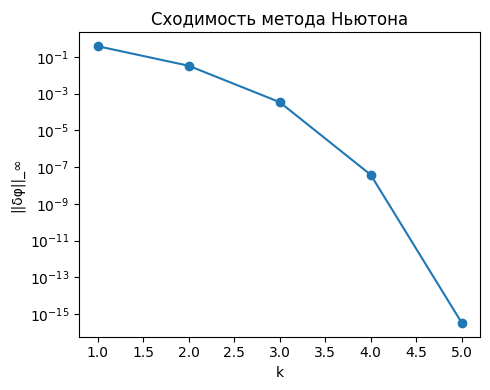

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(range(1, len(norms)+1), norms, 'o-')
ax.set_xlabel('k'); ax.set_ylabel('||δφ||_∞')
ax.set_title('Сходимость метода Ньютона')
plt.tight_layout()
plt.show()

In [16]:
tolerance = 1e-10
iter_to_1e_10 = None

print(f"{'k':>3}  {'||δφ||_∞':>14}")
norms = []
for k in range(30):
    pe = np.concatenate([[0], phi, [0]])
    F4 = (pe[2:] - 2*pe[1:-1] + pe[:-2]) / h4**2 - np.exp(phi) + ni
    diag = -2/h4**2 - np.exp(phi)
    off  = np.ones(N4 - 2) / h4**2
    J = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)
    delta = np.linalg.solve(J, -F4)
    phi += delta
    nm = np.max(np.abs(delta))
    norms.append(nm)
    print(f"{k+1:>3}  {nm:>14.4e}")
    
    if iter_to_1e_10 is None and nm < tolerance:
        iter_to_1e_10 = k + 1  
    
    if nm < 1e-13:
        break


print(f"\nДля достижения точности {tolerance:.0e} потребовалось {iter_to_1e_10} итераций Ньютона.")

  k        ||δφ||_∞
  1      2.2647e-16

Для достижения точности 1e-10 потребовалось 1 итераций Ньютона.


---
# Задание 5. Метод Ньютона с проекционным решением (Галёркин)


In [17]:
# Задание 5. Вариант 4
# -x'' = -(x'^2 + 1)/(1+t^2),  x(0)=0, x(1)=-1/2
# <=> F[x] = x'' + (x'^2+1)/(1+t^2) = 0
# Точное: x*(t) = -t^2/2
#
# Линеаризация F вокруг x_k:
#   w'' + P(t)*w' = -F[x_k],  P = 2*x_k'/(1+t^2),  Q = 0
#
# Начальное приближение: x0 = -t/2  (линейная интерполяция ГУ)

t = np.linspace(0, 1, 3000)

def make_basis(t, n):
    phi, dphi, ddphi = [], [], []
    for k in range(n):
        p   = t**(k+1) * (1 - t)
        dp  = (k+1)*t**k*(1-t) - t**(k+1)
        ddp = (k+1)*k*t**(k-1)*(1-t) - 2*(k+1)*t**k if k > 0 else -2*np.ones_like(t)
        phi.append(p); dphi.append(dp); ddphi.append(ddp)
    return phi, dphi, ddphi

def newton_galerkin_step(xc, dxc, ddxc, t, n_basis=5):
    phi, dphi, ddphi = make_basis(t, n_basis)
    F  = ddxc + (dxc**2 + 1) / (1 + t**2)
    P  = 2*dxc / (1 + t**2)
    Q  = np.zeros_like(t)
    A  = np.zeros((n_basis, n_basis))
    bv = np.zeros(n_basis)
    for j in range(n_basis):
        for k in range(n_basis):
            A[j, k] = np.trapezoid((ddphi[k] + P*dphi[k] + Q*phi[k])*phi[j], t)
        bv[j] = np.trapezoid(-F*phi[j], t)
    c  = np.linalg.solve(A, bv)
    w   = sum(c[i]*phi[i]   for i in range(n_basis))
    dw  = sum(c[i]*dphi[i]  for i in range(n_basis))
    ddw = sum(c[i]*ddphi[i] for i in range(n_basis))
    return xc + w, dxc + dw, ddxc + ddw

x0   = -t / 2
dx0  = -0.5 * np.ones_like(t)
ddx0 = np.zeros_like(t)

x_exact = -t**2 / 2

x1, dx1, ddx1 = newton_galerkin_step(x0, dx0, ddx0, t)
x2, dx2, ddx2 = newton_galerkin_step(x1, dx1, ddx1, t)

e0 = np.max(np.abs(x0 - x_exact))
e1 = np.max(np.abs(x1 - x_exact))
e2 = np.max(np.abs(x2 - x_exact))

print(f"Погрешность x0: {e0:.4e}")
print(f"Погрешность x1: {e1:.4e}")
print(f"Погрешность x2: {e2:.4e}")
print(f"Относительная погрешность x1: {e1/0.5*100:.3f}%")
print(f"Относительная погрешность x2: {e2/0.5*100:.4f}%")

Погрешность x0: 1.2500e-01
Погрешность x1: 4.2007e-03
Погрешность x2: 4.7661e-06
Относительная погрешность x1: 0.840%
Относительная погрешность x2: 0.0010%


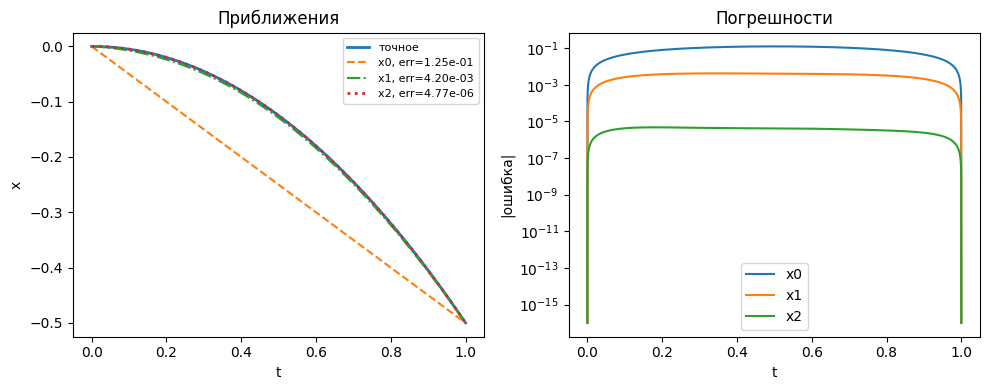

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t, x_exact, '-', lw=2, label='точное')
axes[0].plot(t, x0, '--', label=f'x0, err={e0:.2e}')
axes[0].plot(t, x1, '-.', label=f'x1, err={e1:.2e}')
axes[0].plot(t, x2, ':', lw=2, label=f'x2, err={e2:.2e}')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x')
axes[0].legend(fontsize=8)
axes[0].set_title('Приближения')

axes[1].semilogy(t, np.abs(x0 - x_exact) + 1e-16, label='x0')
axes[1].semilogy(t, np.abs(x1 - x_exact) + 1e-16, label='x1')
axes[1].semilogy(t, np.abs(x2 - x_exact) + 1e-16, label='x2')
axes[1].set_xlabel('t'); axes[1].set_ylabel('|ошибка|')
axes[1].legend(); axes[1].set_title('Погрешности')

plt.tight_layout()
plt.show()